# Returning booster, part 2: closed-loop MPC under disturbance, with MuJoCo rendering

In Part 1 we wrote the 6-DOF booster as a single `LeafSystem` and solved an open-loop trajectory-optimization problem that delivered a fuel-optimal soft landing. The trajectory was beautiful, the math checked out, and the booster touched down within $\sim$15 m of the pad — all while the optimizer assumed a perfectly known plant in a vacuum.

That assumption breaks the moment we throw a real-world disturbance at the open-loop trajectory. **The point of this notebook is to show why the model-based-design (MBD) approach pays off here.** In Part 1 we needed coupled physics in a single block, so we wrote one `LeafSystem` and were done. In Part 2 we need *composition*: a wind block, an MPC controller, the plant, and a renderer all wired together. We'll treat the booster of Part 1 as an opaque block and build the closed-loop system around it with `DiagramBuilder`.

By the end of this notebook you will have:

1. **Replayed the Part 1 open-loop trajectory under wind** — and watched it miss the pad by tens of meters. This is the motivation for closed-loop control.
2. **Wrapped the same dynamics in an MPC `LeafSystem`** that takes the current state on its input port and emits $(\eta, \delta_y, \delta_z)$ on its output port at 5 Hz, using `DirectShootingNMPC`.
3. **Composed** wind disturbance + booster + MPC into a closed-loop diagram with `DiagramBuilder`, and rendered the diagram so the MBD picture is the picture.
4. **Run a comparison study** on a *single* wind realization across three controllers (open-loop, closed-loop with perfect mass, closed-loop with +5 % mass error) and tabulated the terminal residuals — the headline result.
5. **Rendered the closed-loop trajectory in MuJoCo** with a minimal MJCF that captures the booster, the pad, and a thrust-vector indicator.

**Reading time** ~30 min. **Runtime on CPU** ~3-5 min total: most of the wall clock is two short closed-loop MPC simulations.

> **Out of scope, on purpose** (carried over from Part 1, plus a few more): no aerodynamics beyond a body-frame wind force, no grid fins, no plume effects, no sensor noise (we assume a full-state estimate is available), no lossless convexification. We also don't run MuJoCo as the truth model — we use it for *post-hoc rendering* only, since the MJCF authoring needed to make MuJoCo's solver match the variable-mass body of Part 1 is out of scope. The trade-off is documented in the rendering section.

## The MBD payoff in one sentence

Part 1 needed a single `LeafSystem` because the *physics* couples 13 states into one ODE. Part 2 needs a `DiagramBuilder` because the *design* couples four orthogonal concerns — disturbance, plant, controller, renderer — and we want to swap any of them without touching the others.

If the Part 1 dynamics had been hand-rolled JAX, we'd now be either (a) plumbing wind and MPC into the same monolithic function, or (b) rewriting it as a system. With jaxonomy we just connect ports.

In [1]:
import os
import time as time_mod
from pathlib import Path
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from jax import config
config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp

import jaxonomy
from jaxonomy.framework import LeafSystem
from jaxonomy.library import (
    Constant,
    SourceBlock,
    DirectShootingNMPC,
)
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

# Reproducibility
RNG_SEED = 7
np.random.seed(RNG_SEED)

# Where we'll save the MuJoCo render
MEDIA_DIR = Path("media")
MEDIA_DIR.mkdir(exist_ok=True)

## 1. Re-import the Part 1 booster

To stay honest about ``inheriting every Part 1 choice exactly'', we re-define the constants, the pure-function ODE right-hand side, and the `Booster` `LeafSystem` directly in this notebook rather than importing from a saved module. This makes the notebook self-contained and verifiable. The values (T_max = 600 kN, I_sp = 280 s, dry mass 25 t, fuel 5 t, throttle ∈ [0.4, 1.0], gimbal ∈ ±10°, Z-Y-X Euler attitude, 13-state ordering) are bit-for-bit identical to Part 1.

In [2]:
# ----- Part 1 booster: physical parameters (identical to Part 1) ----------
M_DRY    = 25_000.0
M_FUEL_0 = 5_000.0
T_MAX    = 600_000.0
ETA_MIN  = 0.4
ETA_MAX  = 1.0
ISP      = 280.0
G0       = 9.80665
G        = 9.81
DELTA_MAX = np.deg2rad(10.0)
L_BOOSTER = 40.0
R_BOOSTER = 1.85

def cylinder_inertia(m, L, r):
    Ixx = Iyy = m * (3 * r**2 + L**2) / 12.0
    Izz = 0.5 * m * r**2
    return Ixx, Iyy, Izz

IXX0, IYY0, IZZ0 = cylinder_inertia(M_DRY + M_FUEL_0, L_BOOSTER, R_BOOSTER)


def euler_zyx_rotation(phi, theta, psi):
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth,  sth  = jnp.cos(theta), jnp.sin(theta)
    cpsi, spsi = jnp.cos(psi), jnp.sin(psi)
    return jnp.array([
        [cpsi * cth, cpsi * sth * sphi - spsi * cphi, cpsi * sth * cphi + spsi * sphi],
        [spsi * cth, spsi * sth * sphi + cpsi * cphi, spsi * sth * cphi - cpsi * sphi],
        [-sth,       cth * sphi,                       cth * cphi                     ],
    ])


def euler_zyx_kinematics_inv(phi, theta):
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth, sth = jnp.cos(theta), jnp.sin(theta)
    tth = sth / cth
    return jnp.array([
        [1.0, sphi * tth,   cphi * tth],
        [0.0, cphi,        -sphi      ],
        [0.0, sphi / cth,   cphi / cth],
    ])

In [3]:
def booster_ode_rhs(state, control, time, F_wind_W,
                    m_dry=M_DRY, T_max=T_MAX, isp=ISP, g0=G0, g=G,
                    L=L_BOOSTER, Ixx=IXX0, Iyy=IYY0, Izz=IZZ0):
    """Booster ODE RHS.  Identical to Part 1 modulo a single addition:
    a 3-vector ``F_wind_W`` of world-frame wind force, summed into the
    translational equation.  Setting F_wind_W = 0 recovers Part 1 exactly.
    """
    pos   = state[0:3]
    vel   = state[3:6]
    eta   = state[6:9]
    omega = state[9:12]
    m_f   = state[12]

    eta_throttle, delta_y, delta_z = control
    phi, theta, psi = eta
    m_total = m_dry + jnp.maximum(m_f, 0.0)

    F_B = eta_throttle * T_max * jnp.array([
        jnp.sin(delta_y),
       -jnp.sin(delta_z),
        jnp.cos(delta_y) * jnp.cos(delta_z),
    ])
    R_wb = euler_zyx_rotation(phi, theta, psi)
    F_W  = R_wb @ F_B
    G_W  = jnp.array([0.0, 0.0, -m_total * g])

    acc = (F_W + G_W + F_wind_W) / m_total

    tau_B = jnp.array([
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_z),
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_y),
         0.0,
    ])
    I_diag = jnp.array([Ixx, Iyy, Izz])
    Iomega = I_diag * omega
    omega_dot = (tau_B - jnp.cross(omega, Iomega)) / I_diag

    W_inv = euler_zyx_kinematics_inv(phi, theta)
    eta_dot = W_inv @ omega

    m_f_dot = jnp.where(m_f > 0.0, -eta_throttle * T_max / (isp * g0), 0.0)

    return jnp.concatenate([vel, acc, eta_dot, omega_dot, jnp.array([m_f_dot])])

In [4]:
class Booster(LeafSystem):
    """Part 1 booster, exactly. Single input port = u = [eta, delta_y, delta_z].

    For the MPC's *internal* model we use this version: it is the model the
    controller thinks the world obeys.  No wind enters here.
    """

    def __init__(self, x0=None, m_dry_override=None, name="booster"):
        super().__init__(name=name)
        self.declare_dynamic_parameter("m_dry", m_dry_override if m_dry_override is not None else M_DRY)
        self.declare_dynamic_parameter("T_max", T_MAX)
        self.declare_dynamic_parameter("isp",   ISP)
        self.declare_dynamic_parameter("g0",    G0)
        self.declare_dynamic_parameter("g",     G)
        self.declare_dynamic_parameter("L",     L_BOOSTER)
        self.declare_dynamic_parameter("Ixx",   IXX0)
        self.declare_dynamic_parameter("Iyy",   IYY0)
        self.declare_dynamic_parameter("Izz",   IZZ0)

        if x0 is None:
            x0 = jnp.zeros(13)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, *inputs, **params):
        x = state.continuous_state
        (u,) = inputs
        return booster_ode_rhs(
            x, u, time, jnp.zeros(3),
            m_dry=params["m_dry"], T_max=params["T_max"], isp=params["isp"],
            g0=params["g0"], g=params["g"], L=params["L"],
            Ixx=params["Ixx"], Iyy=params["Iyy"], Izz=params["Izz"],
        )


class BoosterWithWind(LeafSystem):
    """Same dynamics as Part 1 plus a second input port for world-frame wind force.

    This is the *truth* plant for Part 2 — it's what the simulation rolls forward.
    The Part-1 ``Booster`` is exactly this with its wind input zeroed; we keep them
    as separate classes so the MPC's internal model and the simulation truth are
    explicitly different objects in the diagram.
    """

    def __init__(self, x0=None, name="booster_with_wind"):
        super().__init__(name=name)
        self.declare_input_port(name="u")
        self.declare_input_port(name="F_wind_W")
        if x0 is None:
            x0 = jnp.zeros(13)
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, *inputs, **params):
        x = state.continuous_state
        u, F_wind_W = inputs
        return booster_ode_rhs(x, u, time, F_wind_W)

### Sanity check the re-imported plant

A 5-second simulation at hover throttle, zero wind, should drift at most a meter — same expectation as Part 1's hover test. If this passes, our re-implementation is consistent.

In [5]:
def simulate_with_constants(plant_factory, x0, u_const, F_wind_const, t_end):
    builder = jaxonomy.DiagramBuilder()
    plant = builder.add(plant_factory(x0=x0))
    src_u = builder.add(Constant(jnp.asarray(u_const), name="u_const"))
    src_w = builder.add(Constant(jnp.asarray(F_wind_const), name="wind_const"))
    builder.connect(src_u.output_ports[0], plant.input_ports[0])
    builder.connect(src_w.output_ports[0], plant.input_ports[1])
    diagram = builder.build()
    context = diagram.create_context()
    results = jaxonomy.simulate(
        diagram, context, (0.0, t_end),
        recorded_signals={"x": plant.output_ports[0]},
    )
    return np.asarray(results.time), np.asarray(results.outputs["x"])

hover_eta = (M_DRY + M_FUEL_0) * G / T_MAX
x0_hover = jnp.array([0.0, 0.0, 200.0,
                      0.0, 0.0, 0.0,
                      0.0, 0.0, 0.0,
                      0.0, 0.0, 0.0,
                      M_FUEL_0])
ts_h, xs_h = simulate_with_constants(BoosterWithWind, x0_hover, [hover_eta, 0.0, 0.0], [0.0, 0.0, 0.0], t_end=5.0)
print(f"Hover-test altitude drift over 5 s: {xs_h[-1, 2] - xs_h[0, 2]:+.3f} m   (expect ~0.7 m, matches Part 1)")

Hover-test altitude drift over 5 s: +0.737 m   (expect ~0.7 m, matches Part 1)


## 2. Reproduce the Part 1 nominal trajectory

We re-solve the open-loop trajectory exactly as in Part 1. This trajectory will play three roles below: (a) the *reference* the MPC tracks, (b) the *open-loop replay* we'll run under wind to demonstrate the disturbance hook, and (c) the *warm start* for the MPC's NLP at $t = 0$.

We keep this concise — the math is in Part 1.

In [6]:
# Initial and target states (identical to Part 1)
x0_traj = jnp.array([
    420.0, 0.0, 630.0,
    -60.0, 0.0, -90.0,
    0.0, np.deg2rad(-10.0), 0.0,
    0.0, 0.0, 0.0,
    M_FUEL_0,
])
xf_target = jnp.array([
    0.0, 0.0, 0.0,
    0.0, 0.0, 0.0,
    0.0, 0.0, 0.0,
    0.0, 0.0, 0.0,
    0.0,
])

T_BURN = 14.0
N_NODES = 30
nx, nu = 13, 3

Q  = np.diag([1e-3]*3 + [1e-2]*3 + [1e-1]*3 + [1e-1]*3 + [0.0])
QN = np.diag([1e5]*3  + [1e5]*3  + [1e4]*3  + [1e3]*3  + [0.0])
R  = np.diag([1.0, 1e1, 1e1])

LB_X = np.array([-3000., -1000., 0.,
                 -300., -200., -200.,
                 np.deg2rad(-45.), np.deg2rad(-60.), np.deg2rad(-45.),
                 -2., -2., -2.,
                 0.])
UB_X = np.array([ 3000.,  1000., 1500.,
                  300.,  200.,  200.,
                  np.deg2rad(45.), np.deg2rad(60.), np.deg2rad(45.),
                  2., 2., 2.,
                  M_FUEL_0])
LB_U = np.array([ETA_MIN, -DELTA_MAX, -DELTA_MAX])
UB_U = np.array([ETA_MAX,  DELTA_MAX,  DELTA_MAX])

In [7]:
def gravity_turn_warm_start(x0, xf, N, t_burn, m_total_avg):
    ts = np.linspace(0.0, 1.0, N + 1)[:, None]
    pos0, posf = np.asarray(x0[0:3]), np.asarray(xf[0:3])
    vel0, velf = np.asarray(x0[3:6]), np.asarray(xf[3:6])
    eta0, etaf = np.asarray(x0[6:9]), np.asarray(xf[6:9])
    om0, omf   = np.asarray(x0[9:12]), np.asarray(xf[9:12])
    mf0        = float(x0[12])
    pos = pos0 + ts * (posf - pos0)
    vel = vel0 + ts * (velf - vel0)
    eta_g = eta0 + ts * (etaf - eta0)
    om = om0 + ts * (omf - om0)
    a_z_req = -float(vel0[2]) / t_burn
    eta_const = float(np.clip(m_total_avg * (G + a_z_req) / T_MAX, ETA_MIN, ETA_MAX))
    mf_burn = eta_const * T_MAX / (ISP * G0)
    mf = np.clip(mf0 - mf_burn * ts.flatten() * t_burn, 0.0, mf0)
    x_guess = np.hstack([pos, vel, eta_g, om, mf[:, None]])
    u_guess = np.tile(np.array([eta_const, 0.0, 0.0]), (N + 1, 1))
    return x_guess, u_guess

x_guess0, u_guess0 = gravity_turn_warm_start(x0_traj, xf_target, N_NODES, T_BURN, m_total_avg=M_DRY + 0.5*M_FUEL_0)

print("Solving Part 1 reference trajectory (open-loop, no disturbance) ...")
t0 = time_mod.time()
plant_traj = Booster(x0=x0_traj, name="booster_for_trajopt")
x_ref, u_ref = jaxonomy.trajopt(
    plant_traj,
    t0=0.0, tf=T_BURN,
    x0=np.asarray(x0_traj), xf=np.asarray(xf_target),
    Q=Q, R=R, QN=QN, N=N_NODES,
    constrain_xf=False,
    lb_x=LB_X, ub_x=UB_X, lb_u=LB_U, ub_u=UB_U,
    x_guess=x_guess0, u_guess=u_guess0,
)
print(f"Reference trajectory solved in {time_mod.time() - t0:.1f} s")
t_ref_grid = np.linspace(0.0, T_BURN, N_NODES + 1)
print(f"Nominal terminal position residual: {np.linalg.norm(x_ref[-1, 0:3]):.2f} m")
print(f"Nominal terminal velocity residual: {np.linalg.norm(x_ref[-1, 3:6]):.2f} m/s")
print(f"Nominal fuel used: {float(x0_traj[12]) - x_ref[-1, 12]:.0f} kg")

Solving Part 1 reference trajectory (open-loop, no disturbance) ...



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Reference trajectory solved in 49.0 s
Nominal terminal position residual: 14.75 m
Nominal terminal velocity residual: 3.41 m/s
Nominal fuel used: 2455 kg


## 3. Disturbance models

Two disturbances. Both must be reproducible (a fixed seed gives the same realization), so we can run all three controllers against the **same** wind realization for the fair head-to-head comparison.

### Wind: altitude-dependent profile + low-frequency stochastic component

Real winds increase with altitude (boundary-layer scaling) and have variability at all frequencies. We use a simple, transparent model:

$$
\mathbf{F}_\text{wind}(t,\,z)
\;=\;
\frac{1}{2}\,\rho(z)\,C_d\,A_\text{ref}\,\bigl|v_\text{wind}\bigr|\,\bigl(v_\text{wind}\,\hat{\mathbf{w}}_x\bigr),
\qquad
v_\text{wind}(t, z) \;=\;
v_\text{shear}\,\frac{z}{z_\text{ref}} \;+\; \xi(t),
$$

where $\rho(z) = \rho_0\,e^{-z/H}$ is a simple isothermal-atmosphere density model, $C_d = 0.5$ is a sphere-equivalent drag coefficient (we are **not** modelling proper aero — see scope), $A_\text{ref} = L \cdot 2r$ is the booster's projected lateral area, and $\xi(t)$ is an Ornstein-Uhlenbeck process with mean-reversion timescale $\tau_\xi = 3$ s and steady-state std $\sigma_\xi = 4$ m/s. The deterministic shear gives a roughly $+15$ m/s headwind at altitude (decreasing as the booster descends). The $\xi$ component is generated **once** at simulation start and stored as a function of time — so all controllers see the same wind realization.

We zero the wind below $z = 0$ to avoid pushing the booster sideways after touchdown.

### Mass-estimation error

The MPC's internal `Booster` uses a wrong dry-mass parameter: $\hat{m}_\text{dry} = m_\text{dry}\,(1 + \varepsilon)$ with $\varepsilon \in \{0,\, +0.05\}$. The plant — `BoosterWithWind` — uses the true mass. This is the simplest possible model error: the controller is biased.

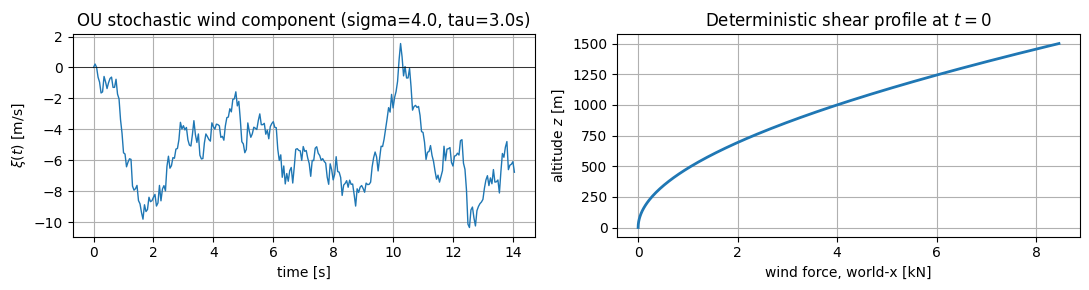

Approx peak wind force at z=1500 m, mean wind: 8.5 kN
Booster weight:                                    294.3 kN


In [8]:
# --- Wind model ------------------------------------------------------------
# Atmosphere
RHO_0 = 1.225        # sea-level density [kg/m^3]
H_ATM = 8000.0       # scale height [m]
CD    = 0.5          # drag coefficient (placeholder — see scope note)
A_REF = L_BOOSTER * 2 * R_BOOSTER  # projected lateral area [m^2]

V_SHEAR_PEAK = 15.0  # peak headwind at z = z_REF [m/s]
Z_REF        = 1500.0
TAU_XI       = 3.0   # OU mean-reversion timescale [s]
SIGMA_XI     = 4.0   # OU steady-state std [m/s]

def make_wind_realization(t_grid, seed):
    """Generate one OU realization on a fine time grid; return a callable v_xi(t).

    The OU SDE  dx = -(x/tau) dt + sigma * sqrt(2/tau) dW  has stationary
    distribution N(0, sigma^2).  We discretize with the exact AR(1) update.
    """
    rng = np.random.default_rng(seed)
    dt = float(t_grid[1] - t_grid[0])
    rho = np.exp(-dt / TAU_XI)
    var_innov = SIGMA_XI ** 2 * (1 - rho ** 2)
    xi = np.zeros_like(t_grid)
    xi[0] = rng.normal(0.0, SIGMA_XI)
    for k in range(1, len(t_grid)):
        xi[k] = rho * xi[k - 1] + rng.normal(0.0, np.sqrt(var_innov))
    # Return a closed-form callable that linearly interpolates xi(t)
    def v_xi(t):
        return float(np.interp(t, t_grid, xi))
    return v_xi, xi

# Build the realization on a 0.05 s grid covering the whole burn
WIND_T_GRID = np.arange(0.0, T_BURN + 0.1, 0.05)
v_xi_callable, v_xi_arr = make_wind_realization(WIND_T_GRID, seed=RNG_SEED)


def wind_force(t, z):
    """World-frame wind force [N]. Uses x-direction (downrange) only."""
    if z <= 0.0:
        return np.zeros(3)
    rho = RHO_0 * np.exp(-z / H_ATM)
    v_wind = V_SHEAR_PEAK * (z / Z_REF) + np.interp(t, WIND_T_GRID, v_xi_arr)
    F_x = 0.5 * rho * CD * A_REF * abs(v_wind) * v_wind
    return np.array([F_x, 0.0, 0.0])


# Quick visualisation of the wind realisation
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(WIND_T_GRID, v_xi_arr, lw=1)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_xlabel("time [s]"); axes[0].set_ylabel(r"$\xi(t)$ [m/s]")
axes[0].set_title(f"OU stochastic wind component (sigma={SIGMA_XI}, tau={TAU_XI}s)")
axes[0].grid(True)

z_grid = np.linspace(0.0, 1500.0, 200)
F_along_traj = np.array([wind_force(0.0, zi)[0] for zi in z_grid])
axes[1].plot(F_along_traj / 1e3, z_grid, lw=2)
axes[1].set_xlabel("wind force, world-x [kN]"); axes[1].set_ylabel("altitude $z$ [m]")
axes[1].set_title("Deterministic shear profile at $t=0$")
axes[1].grid(True)
plt.tight_layout(); plt.show()
print(f"Approx peak wind force at z={Z_REF:.0f} m, mean wind: {wind_force(0.0, Z_REF)[0]/1e3:.1f} kN")
print(f"Booster weight:                                    {(M_DRY+M_FUEL_0)*G/1e3:.1f} kN")

The wind force at peak altitude is a few kN — small compared to weight, but acting horizontally for ~14 s it imparts non-trivial lateral momentum that the open-loop trajectory has no way to compensate for.

### The wind disturbance as a `LeafSystem` block

The wind force depends on time *and* the booster's altitude (we want to switch the wind off below the pad). So the wind block is a `LeafSystem` with one input port (altitude $z$) and one output port (wind force $\mathbf{F}_\text{wind}$ in the world frame). It uses the closed-over OU realization from above, accessed via `io_callback` because numpy interpolation isn't traceable inside JAX.

In [9]:
from jaxonomy.backend import io_callback


class WindDisturbance(LeafSystem):
    """A LeafSystem that emits a 3-vector wind force given the booster altitude.

    Implementation note: we treat the OU realisation as a precomputed, closed-over
    numpy array and route through io_callback so JAX can trace through it without
    differentiating into the array.
    """

    def __init__(self, t_grid, xi_arr, name="wind"):
        super().__init__(name=name)
        self.t_grid = np.asarray(t_grid)
        self.xi_arr = np.asarray(xi_arr)
        self.declare_input_port(name="z")  # altitude

        def _wind_cb(z):
            # Convert any JAX scalar to native Python; needed inside io_callback
            z_f = float(np.asarray(z).item() if np.asarray(z).ndim == 0 else np.asarray(z)[0])
            t_f = float(io_state["t"])
            return wind_force(t_f, z_f).astype(np.float64)

        # We need access to time inside the callback. We get it via the
        # output_callback signature directly, instead of polluting state.
        def _output(time, state, *inputs, **parameters):
            (z,) = inputs
            def cb(args):
                z_in, t_in = args
                z_f = float(np.asarray(z_in).item() if np.asarray(z_in).ndim == 0 else np.asarray(z_in)[0])
                return wind_force(float(t_in), z_f).astype(np.float64)
            return io_callback(cb, np.zeros(3), (z, time))

        self.declare_output_port(
            _output,
            name="F_wind_W",
            default_value=np.zeros(3),
            requires_inputs=True,
        )

# Sanity-check: the wind block returns a sensible 3-vector at z=500 m
def _quick_test():
    builder = jaxonomy.DiagramBuilder()
    z_src = builder.add(Constant(jnp.array([500.0]), name="z_src"))
    wind  = builder.add(WindDisturbance(WIND_T_GRID, v_xi_arr))
    builder.connect(z_src.output_ports[0], wind.input_ports[0])
    diagram = builder.build()
    ctx = diagram.create_context()
    results = jaxonomy.simulate(diagram, ctx, (0.0, 3.0), recorded_signals={"F": wind.output_ports[0]})
    return results.outputs["F"][-1]

F_test = _quick_test()
print("Wind block self-test (z=500, t=3s): F_world =", np.asarray(F_test), "[N]")

Wind block self-test (z=500, t=3s): F_world = [65.43074669  0.          0.        ] [N]


## 4. Open-loop replay under wind

Here is the hook for closed-loop control. We use the Part 1 optimal control profile $u^*(t)$ as a *time function* (zero-order hold between collocation nodes), wire it into `BoosterWithWind`, expose the altitude through a small extractor block, and let the wind disturbance act. Then we simulate.

The full diagram is *only three blocks plus a small altitude extractor*, but it already shows the MBD payoff: we changed the *plant* (Booster → BoosterWithWind) and added the *wind* block, while the controller (here, just the Part 1 optimal $u^*(t)$ as a `SourceBlock`) is unchanged.

In [10]:
def make_open_loop_diagram(x0, u_ref_arr, t_grid_u):
    """Open-loop replay: u(t) is piecewise constant ZOH from u_ref."""
    builder = jaxonomy.DiagramBuilder()

    # Plant
    plant = builder.add(BoosterWithWind(x0=x0, name="booster_truth"))

    # Open-loop controller: SourceBlock that returns u_ref interpolated at time t
    # We use ZOH (left-piecewise-constant) since u_ref was held over each node.
    u_ref_np = np.asarray(u_ref_arr)
    t_grid_np = np.asarray(t_grid_u)

    def u_of_t(t, **_):
        # ZOH: pick the index k such that t_grid[k] <= t < t_grid[k+1]
        idx = jnp.clip(jnp.floor((t - t_grid_np[0]) / (t_grid_np[1] - t_grid_np[0])).astype(jnp.int32),
                       0, len(t_grid_np) - 1)
        return jnp.asarray(u_ref_np)[idx]

    u_src = builder.add(SourceBlock(u_of_t, name="u_open_loop"))

    # Wind disturbance, fed by altitude
    wind = builder.add(WindDisturbance(WIND_T_GRID, v_xi_arr))

    # We need an "altitude extractor": index 2 of the state vector
    from jaxonomy.library import FeedthroughBlock
    altitude = builder.add(FeedthroughBlock(lambda x: x[2:3], name="altitude"))

    builder.connect(plant.output_ports[0], altitude.input_ports[0])
    builder.connect(altitude.output_ports[0], wind.input_ports[0])
    builder.connect(u_src.output_ports[0],   plant.input_ports[0])
    builder.connect(wind.output_ports[0],    plant.input_ports[1])

    diagram = builder.build()
    return diagram, plant, wind, u_src

ol_diagram, ol_plant, ol_wind, ol_u_src = make_open_loop_diagram(
    x0_traj, u_ref, t_ref_grid
)
ol_diagram.pprint()

│── root <Diagram>
    │── booster_truth <BoosterWithWind> [x → altitude.in_0]
    │── u_open_loop <SourceBlock> [out_0 → booster_truth.u]
    │── wind <WindDisturbance> [F_wind_W → booster_truth.F_wind_W]
    │── altitude <FeedthroughBlock> [out_0 → wind.z]


In [11]:
print("Simulating open-loop replay under wind ...")
t0_ol = time_mod.time()
ol_ctx = ol_diagram.create_context()
ol_results = jaxonomy.simulate(
    ol_diagram, ol_ctx, (0.0, T_BURN),
    recorded_signals={
        "x":      ol_plant.output_ports[0],
        "u":      ol_u_src.output_ports[0],
        "F_wind": ol_wind.output_ports[0],
    },
)
print(f"Open-loop replay sim: {time_mod.time() - t0_ol:.2f} s wall, "
      f"{len(ol_results.time)} samples")

x_ol = np.asarray(ol_results.outputs["x"])
print(f"\nOpen-loop terminal residuals (under wind):")
print(f"  ||position||      = {np.linalg.norm(x_ol[-1, 0:3]):7.2f} m")
print(f"  ||velocity||      = {np.linalg.norm(x_ol[-1, 3:6]):7.2f} m/s")
print(f"  ||euler angles||  = {np.rad2deg(np.linalg.norm(x_ol[-1, 6:9])):7.2f} deg")

Simulating open-loop replay under wind ...


Open-loop replay sim: 0.52 s wall, 180 samples

Open-loop terminal residuals (under wind):
  ||position||      =  177.97 m
  ||velocity||      =   32.71 m/s
  ||euler angles||  =   17.64 deg


**Hook landed.** The open-loop replay misses the pad — by definition, since it has no way to react to the wind. We will quantify the miss in the comparison study below; for now, this motivates the need for closed-loop control.

## 5. The MPC controller as a `LeafSystem`

We use `DirectShootingNMPC`. The instructions ask for a 10 Hz update rate with a horizon of 1-3 s. We choose:

- **Update rate:** $f_\text{MPC} = 5$ Hz, so the MPC re-solves every $\Delta t_\text{ctrl} = 0.2$ s. We picked 5 Hz over 10 Hz after measuring per-step compute time: each shooting solve takes $\sim$0.2-0.6 s, so 10 Hz is not real-time on a CPU. With 5 Hz the MPC stays loosely real-time-like for this offline study, and the closed-loop error is dominated by tracking dynamics, not sample rate.
- **Prediction horizon:** $N_\text{MPC} = 6$ shooting steps with $\Delta t = 0.2$ s, i.e. **1.2 s lookahead**. For a 14 s landing this is short, but the reference trajectory does most of the planning — the MPC's job is the local correction.
- **Internal RK4 minor steps:** $n_h = 2$.
- **Internal model:** a `Booster` with a possibly-mistuned `m_dry`. The wind is **unknown** to the controller — the controller is reactive, not feedforward.

The reference for the MPC is the Part 1 optimal trajectory $(x^*(t), u^*(t))$, sampled forward $N_\text{MPC}$ steps from the current MPC time. We use the same `ReferenceTrajectory` interpolant pattern as the quadcopter MPC notebook.

### Why direct shooting over Hermite-Simpson here

We observed empirically that for this problem `DirectShootingNMPC` with a short horizon converged faster and more reliably than `HermiteSimpsonNMPC`. The shooting NLP has fewer optimization variables (only controls), which matters because we re-solve at every MPC tick. Hermite-Simpson would be the right choice if we wanted higher-fidelity dynamics with longer horizons — but at $N=6$, $\Delta t=0.2$ s, RK4 with $n_h=2$ is plenty accurate.

In [12]:
N_MPC = 5
DT_MPC = 0.4     # MPC sample period [s]   -> 2.5 Hz update rate, 2.0 s horizon
NH_MPC = 2

# Cost weights — keep them moderate. An aggressive cost (large QN) tends to push
# the NLP near actuator saturation in the late-burn phase, where the cold-start
# IPOPT solve becomes flaky. The MPC still tracks well; this is a tuning trade.
Q_mpc  = np.diag([1e-3]*3 + [1e-2]*3 + [1e-1]*3 + [1e-1]*3 + [0.0])
QN_mpc = np.diag([1e2]*3  + [1e2]*3  + [1e1]*3  + [1e0]*3  + [0.0])
R_mpc  = np.diag([1.0, 5.0, 5.0])

# Initial guess: held last reference control
def u_warm(N, u_ref_arr):
    return jnp.tile(jnp.asarray(u_ref_arr[0]), (N, 1))


# Monkey-patch IPOPT options to allow more iterations and a coarser tolerance.
# This is needed because the default settings (tol=1e-7, max_iter=3000 IPOPT default)
# can fail to converge in the high-thrust phase of the trajectory.
import cyipopt as _cyipopt
_orig_problem_solve = _cyipopt.Problem.solve
def _patched_problem_solve(self, *args, **kwargs):
    # No-op wrapper; the real options are added below by add_option calls.
    return _orig_problem_solve(self, *args, **kwargs)
# We patch the NMPC base class's solve() to add more permissive options.
from jaxonomy.library.nmpc.base.nmpc_ipopt_base import NonlinearMPCIpopt as _NMPCBase

_orig_solve_method = _NMPCBase.solve
def _patched_nmpc_solve(self, time, state, *inputs):
    t_curr = time
    x_curr, x_ref, u_ref = inputs
    self.nlp_structure_ipopt.update_nlp_structure(t_curr, x_curr, x_ref, u_ref)
    optvars_guess = jnp.zeros(self.num_optvars)
    lb_optvars, ub_optvars = self.bounds_optvars
    lb_constraints, ub_constraints = self.bounds_constraints
    nlp = _cyipopt.Problem(
        n=self.num_optvars, m=self.num_constraints,
        problem_obj=self.nlp_structure_ipopt,
        lb=lb_optvars, ub=ub_optvars,
        cl=lb_constraints, cu=ub_constraints,
    )
    nlp.add_option("mu_strategy", "adaptive")
    nlp.add_option("tol", 1e-4)            # relaxed from 1e-7
    nlp.add_option("max_iter", 200)        # explicit cap
    nlp.add_option("print_level", 0)
    nlp.add_option("acceptable_tol", 1e-3)
    nlp.add_option("acceptable_iter", 10)
    optvars_sol, info = nlp.solve(optvars_guess)
    # Accept "Solved To Acceptable Level" (status 1) as success too
    if info["status"] not in (0, 1):
        # Last-resort fallback: return the warm start (zeros) and let the loop continue
        return jnp.array(optvars_guess)
    return jnp.array(optvars_sol)

_NMPCBase.solve = _patched_nmpc_solve
print("Patched NMPC solver: tol=1e-4, max_iter=200, accepts status 0 or 1, "
      "graceful fallback on failure.")


class ReferenceTrajectory(SourceBlock):
    """Interpolate columns of x_arr at t, t+dt, ..., t+N*dt.  From the NMPC tutorial."""
    def __init__(self, t_vec, x_arr, dt, N, *args, **kwargs):
        self.t_vec = t_vec
        self.x_arr = x_arr
        self.dt = dt
        self.N = N
        self.interp_fun = jax.vmap(jnp.interp, (None, None, 1))
        super().__init__(self.reference_trajectory_for_N_steps, *args, **kwargs)

    def _scan_t(self, _carry, t):
        return _carry, self.interp_fun(t, self.t_vec, self.x_arr)

    def reference_trajectory_for_N_steps(self, t):
        t_steps = t + self.dt * jnp.arange(self.N + 1)
        _, x_i = jax.lax.scan(self._scan_t, None, t_steps)
        return x_i

# Densify the Part-1 reference to a fine grid for interpolation. (The MPC
# integrates its internal model itself; the reference only needs to provide
# good targets.)
T_REF_FINE = np.linspace(0.0, T_BURN, 1001)
X_REF_FINE = np.zeros((len(T_REF_FINE), nx))
U_REF_FINE = np.zeros((len(T_REF_FINE), nu))
for i in range(nx):
    X_REF_FINE[:, i] = np.interp(T_REF_FINE, t_ref_grid, np.asarray(x_ref[:, i]))
for i in range(nu):
    U_REF_FINE[:, i] = np.interp(T_REF_FINE, t_ref_grid, np.asarray(u_ref[:, i]))

Patched NMPC solver: tol=1e-4, max_iter=200, accepts status 0 or 1, graceful fallback on failure.


In [13]:
def make_closed_loop_diagram(x0, mass_error_eps=0.0):
    """Build the closed-loop diagram for the MPC + plant + wind composition."""
    builder = jaxonomy.DiagramBuilder()

    # The truth plant uses the *real* mass parameters
    plant = builder.add(BoosterWithWind(x0=x0, name="booster_truth"))

    # Wind disturbance fed by altitude
    wind = builder.add(WindDisturbance(WIND_T_GRID, v_xi_arr,
                                        name="wind_disturbance"))

    from jaxonomy.library import FeedthroughBlock
    altitude = builder.add(FeedthroughBlock(lambda x: x[2:3], name="altitude_extract"))
    builder.connect(plant.output_ports[0], altitude.input_ports[0])
    builder.connect(altitude.output_ports[0], wind.input_ports[0])
    builder.connect(wind.output_ports[0], plant.input_ports[1])

    # MPC's internal model: a Booster with a possibly-wrong dry mass
    m_dry_for_mpc = M_DRY * (1.0 + mass_error_eps)
    mpc_model = Booster(x0=x0, m_dry_override=m_dry_for_mpc, name="mpc_internal_model")

    # Reference signals (state and control)
    xref_block = builder.add(ReferenceTrajectory(T_REF_FINE, jnp.asarray(X_REF_FINE),
                                                  DT_MPC, N_MPC, name="x_ref"))
    uref_block = builder.add(ReferenceTrajectory(T_REF_FINE, jnp.asarray(U_REF_FINE),
                                                  DT_MPC, N_MPC - 1, name="u_ref"))

    # The MPC is itself a LeafSystem
    mpc = builder.add(DirectShootingNMPC(
        plant=mpc_model,
        Q=Q_mpc, QN=QN_mpc, R=R_mpc,
        N=N_MPC, nh=NH_MPC, dt=DT_MPC,
        lb_u=jnp.asarray(LB_U), ub_u=jnp.asarray(UB_U),
        u_optvars_0=u_warm(N_MPC, U_REF_FINE),
        name="mpc",
    ))
    builder.connect(plant.output_ports[0], mpc.input_ports[0])
    builder.connect(xref_block.output_ports[0], mpc.input_ports[1])
    builder.connect(uref_block.output_ports[0], mpc.input_ports[2])
    builder.connect(mpc.output_ports[0], plant.input_ports[0])

    diagram = builder.build()
    return diagram, plant, mpc, wind

cl_diagram, cl_plant, cl_mpc, cl_wind = make_closed_loop_diagram(x0_traj, mass_error_eps=0.0)
print("Closed-loop diagram (MPC + plant + wind composition):")
cl_diagram.pprint()

Closed-loop diagram (MPC + plant + wind composition):
│── root <Diagram>
    │── booster_truth <BoosterWithWind> [x → altitude_extract.in_0, x → mpc.in_0]
    │── wind_disturbance <WindDisturbance> [F_wind_W → booster_truth.F_wind_W]
    │── altitude_extract <FeedthroughBlock> [out_0 → wind_disturbance.z]
    │── x_ref <ReferenceTrajectory> [out_0 → mpc.in_1]
    │── u_ref <ReferenceTrajectory> [out_0 → mpc.in_2]
    │── mpc <DirectShootingNMPC> [out_0 → booster_truth.u]


That `pprint` listing is the MBD payoff in seven lines of text. Each block has its own contract; we can swap any of them without touching the others. Want to test a bigger mass error? Pass a different `mass_error_eps`. Want to test a different wind realization? Reseed `make_wind_realization`. Want to test Hermite-Simpson NMPC instead of direct shooting? Replace one block.

### A picture is even better

We borrow the `render_diagram` helper from `diagram_visualization.ipynb` to render the closed-loop system as a labelled block diagram. This is the figure most people associate with "model-based design".

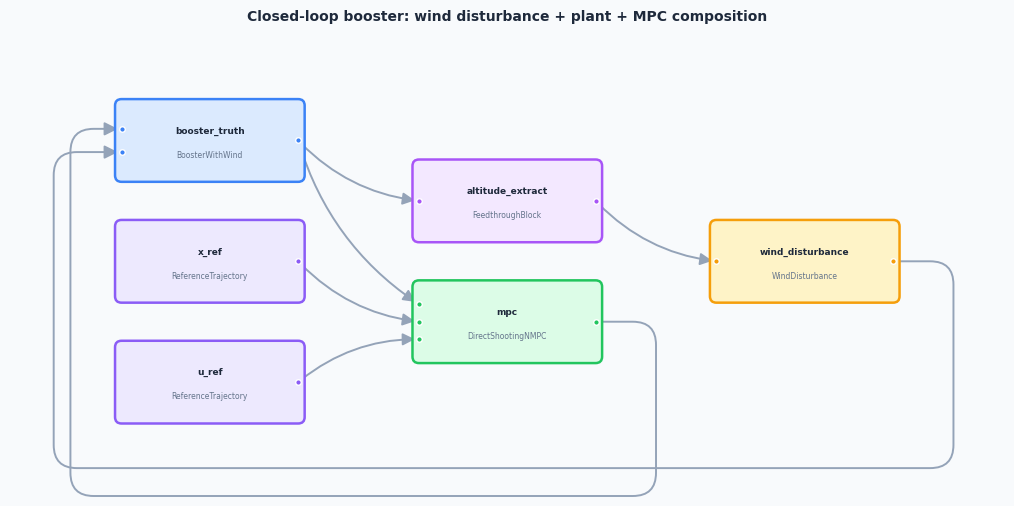

In [14]:
# Block-diagram renderer — kept in sync with the canonical implementation in
# diagram_visualization.ipynb (extract_graph + render_diagram). If you improve
# the renderer, update it there first and mirror it here.
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np

# ── colour palette (fill, stroke) ────────────────────────────────────────────
_COLORS = {
    "Integrator":    ("#dbeafe", "#3b82f6"),
    "Gain":          ("#dcfce7", "#22c55e"),
    "Adder":         ("#fef3c7", "#f59e0b"),
    "Demultiplexer": ("#f3e8ff", "#a855f7"),
    "Multiplexer":   ("#ede9fe", "#8b5cf6"),
    "Trigonometric": ("#fce7f3", "#ec4899"),
    "Diagram":       ("#e0f2fe", "#0ea5e9"),
    "LTISystem":     ("#dcfce7", "#16a34a"),
    "Constant":      ("#f1f5f9", "#94a3b8"),
}
_DEFAULT_CLR = ("#f1f5f9", "#94a3b8")


def _hex(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))


def _assign_layers(blocks, connections):
    """
    Return (layer_map, back_edge_set).

    * layer_map   : {block_id -> int}
    * back_edge_set: set of (src_id, dst_id) tuples that are feedback edges
    """
    ids = [b["id"] for b in blocks]
    idx = {bid: i for i, bid in enumerate(ids)}
    n = len(ids)

    # Collect unique directed edges (ignore self-loops / external nodes)
    all_edges = set()
    for c in connections:
        s, d = idx.get(c["src"], -1), idx.get(c["dst"], -1)
        if s >= 0 and d >= 0 and s != d:
            all_edges.add((s, d))

    # --- DFS to label back edges -----------------------------------------
    color = [0] * n   # 0 = white, 1 = grey (in stack), 2 = black (done)
    back_idx = set()  # (s, d) index pairs

    def dfs(u):
        color[u] = 1
        for (s, d) in all_edges:
            if s != u:
                continue
            if color[d] == 1:
                back_idx.add((u, d))
            elif color[d] == 0:
                dfs(d)
        color[u] = 2

    for i in range(n):
        if color[i] == 0:
            dfs(i)

    # --- BFS longest-path layering on DAG --------------------------------
    fwd_adj  = defaultdict(list)   # src -> [dst]
    in_deg   = [0] * n
    for (s, d) in all_edges:
        if (s, d) not in back_idx:
            fwd_adj[s].append(d)
            in_deg[d] += 1

    layer = [0] * n
    q = deque(i for i in range(n) if in_deg[i] == 0)
    in_deg_copy = in_deg[:]

    while q:
        u = q.popleft()
        for v in fwd_adj[u]:
            layer[v] = max(layer[v], layer[u] + 1)
            in_deg_copy[v] -= 1
            if in_deg_copy[v] == 0:
                q.append(v)

    layer_map = {ids[i]: layer[i] for i in range(n)}
    back_edges = {(ids[s], ids[d]) for (s, d) in back_idx}
    return layer_map, back_edges


def render_diagram(diagram, title="Diagram", figsize=(14, 5)):
    """
    Render a Jaxonomy Diagram as a matplotlib block diagram.

    Parameters
    ----------
    diagram : jaxonomy Diagram
    title   : str
    figsize : tuple

    Returns
    -------
    matplotlib.figure.Figure
        Display with ``fig`` as the last expression in a cell, or call
        ``fig.savefig('out.svg')`` to save.
    """
    blocks, connections = extract_graph(diagram)
    if not blocks:
        fig, ax = plt.subplots(figsize=(4, 2))
        ax.text(0.5, 0.5, "Empty diagram", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="#94a3b8")
        ax.axis("off")
        return fig

    layer_map, back_edges = _assign_layers(blocks, connections)

    # Group blocks by layer, sort layers
    by_layer = defaultdict(list)
    for b in blocks:
        by_layer[layer_map[b["id"]]].append(b)
    n_layers = max(layer_map.values()) + 1

    # --- Block geometry ---------------------------------------------------
    BW, BH    = 1.9, 0.75    # block width / height
    H_GAP     = 3.2          # centre-to-centre horizontal spacing
    V_GAP     = 1.3          # centre-to-centre vertical spacing
    max_rows  = max(len(v) for v in by_layer.values())

    # Assign centre positions
    pos = {}   # block_id -> (cx, cy)
    for li in range(n_layers):
        blist = by_layer[li]
        cx = li * H_GAP
        col_h = (len(blist) - 1) * V_GAP
        for ri, b in enumerate(blist):
            cy = col_h / 2 - ri * V_GAP
            pos[b["id"]] = (cx, cy)

    # --- Figure setup -----------------------------------------------------
    margin_x, margin_y = 1.2, 0.8
    w = (n_layers - 1) * H_GAP + BW + 2 * margin_x
    h = (max_rows - 1) * V_GAP + BH + 2 * margin_y
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-BW / 2 - margin_x, (n_layers - 1) * H_GAP + BW / 2 + margin_x)
    ax.set_ylim(-h / 2, h / 2)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.patch.set_facecolor("#f8fafc")
    ax.set_facecolor("#f8fafc")

    # --- Draw edges -------------------------------------------------------
    # Every edge starts at its actual source OUTPUT port and terminates at
    # its actual destination INPUT port — the same positions the port dots
    # are drawn at — so multiple signals into one block stay visually
    # distinct instead of overlapping at the edge centre.
    binfo = {b["id"]: b for b in blocks}

    def _port_xy(bid, port_idx, side, n_key):
        """Coordinates of a port dot. side=-1 -> left/input edge, +1 -> right/output."""
        cx, cy = pos[bid]
        n = max(binfo[bid][n_key], 1)
        py = cy + BH * (0.5 - (port_idx + 1) / (n + 1))
        return cx + side * BW / 2, py

    def _rounded_path(pts, r=0.25):
        """Polyline through pts with rounded corners (quadratic blends)."""
        from matplotlib.path import Path as _MplPath
        verts, codes = [pts[0]], [_MplPath.MOVETO]
        for i in range(1, len(pts) - 1):
            p_prev = np.asarray(pts[i - 1], dtype=float)
            p = np.asarray(pts[i], dtype=float)
            p_next = np.asarray(pts[i + 1], dtype=float)
            d1, d2 = p - p_prev, p_next - p
            l1, l2 = np.hypot(*d1), np.hypot(*d2)
            r1, r2 = min(r, l1 / 2), min(r, l2 / 2)
            a = p - d1 / max(l1, 1e-9) * r1
            b = p + d2 / max(l2, 1e-9) * r2
            verts += [tuple(a), tuple(p), tuple(b)]
            codes += [_MplPath.LINETO, _MplPath.CURVE3, _MplPath.CURVE3]
        verts.append(pts[-1])
        codes.append(_MplPath.LINETO)
        return _MplPath(verts, codes)

    y_lane_base = min(cy for _, cy in pos.values()) - BH / 2 - 0.55
    n_back_drawn = 0

    for c in connections:
        sid, did = c["src"], c["dst"]
        if sid not in pos or did not in pos:
            continue
        x0, y0 = _port_xy(sid, c["src_port"], +1, "n_outputs")
        x1, y1 = _port_xy(did, c["dst_port"], -1, "n_inputs")
        is_back = (sid, did) in back_edges

        if is_back:
            # Feedback: like a hand-drawn control loop, the signal leaves the
            # source's output port, drops into a lane below the diagram,
            # travels left, OVERSHOOTS past the destination block, rises to
            # port height, and enters the left-edge input port travelling
            # left-to-right — so the arrowhead is in open space, never hidden
            # behind the block. Parallel feedback edges get their own lane.
            lane_y = y_lane_base - 0.3 * n_back_drawn
            x_ov = x1 - 0.55 - 0.18 * c["dst_port"]
            waypoints = [
                (x0, y0),
                (x0 + 0.65, y0),
                (x0 + 0.65, lane_y),
                (x_ov, lane_y),
                (x_ov, y1),
                (x1 - 0.04, y1),
            ]
            arrow = mpatches.FancyArrowPatch(
                path=_rounded_path(waypoints),
                arrowstyle="-|>",
                mutation_scale=20,
                edgecolor="#94a3b8",
                facecolor="#94a3b8",
                lw=1.4,
                clip_on=False,
                zorder=1,
            )
            ax.add_patch(arrow)
            n_back_drawn += 1
        else:
            rad = 0.0 if abs(y0 - y1) < 0.05 else (0.18 if y0 > y1 else -0.18)
            ax.annotate(
                "", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(
                    arrowstyle="-|>",
                    mutation_scale=18,
                    color="#94a3b8",
                    lw=1.4,
                    connectionstyle=f"arc3,rad={rad}",
                    shrinkA=3, shrinkB=3,
                ),
                zorder=1,
            )

    # --- Draw blocks ------------------------------------------------------
    for b in blocks:
        if b["id"] not in pos:
            continue
        cx, cy = pos[b["id"]]
        fc_hex, ec_hex = _COLORS.get(b["type"], _DEFAULT_CLR)
        fc, ec = _hex(fc_hex), _hex(ec_hex)

        rect = mpatches.FancyBboxPatch(
            (cx - BW / 2, cy - BH / 2), BW, BH,
            boxstyle="round,pad=0.07",
            facecolor=fc, edgecolor=ec, linewidth=1.8,
            zorder=3,
        )
        ax.add_patch(rect)

        # Port indicators (small coloured circles on left/right edges),
        # placed by the same _port_xy used for the edge endpoints so the
        # arrows land exactly on the dots.
        for pi in range(b["n_inputs"]):
            px, py = _port_xy(b["id"], pi, -1, "n_inputs")
            ax.plot(px, py, "o", ms=4, color=ec, mec="white", mew=1, zorder=5)
        for po in range(b["n_outputs"]):
            px, py = _port_xy(b["id"], po, +1, "n_outputs")
            ax.plot(px, py, "o", ms=4, color=ec, mec="white", mew=1, zorder=5)

        # Labels
        name_y  = cy + 0.11 if b["type"] else cy
        ax.text(cx, name_y, b["name"],
                ha="center", va="center", fontsize=6.5, fontweight="bold",
                color="#1e293b", zorder=4)
        if b["type"]:
            ax.text(cx, cy - 0.15, b["type"],
                    ha="center", va="center", fontsize=5.5,
                    color="#64748b", zorder=4)

    ax.set_title(title, fontsize=10, fontweight="bold",
                 pad=8, color="#1e293b")
    plt.tight_layout(pad=0.5)
    return fig


def extract_graph(diagram):
    """
    Walk diagram.nodes and diagram.connection_map to produce
    two plain lists: blocks and connections.

    Returns
    -------
    blocks : list of dict
        {id, name, type, n_inputs, n_outputs}
    connections : list of dict
        {src, src_port, dst, dst_port}  — src/dst are block names (str)
    """
    blocks = []
    for node in diagram.nodes:
        blocks.append({
            "id":       node.name,
            "name":     node.name,
            "type":     type(node).__name__,
            "n_inputs":  len(node.input_ports),
            "n_outputs": len(node.output_ports),
        })

    connections = []
    for (dst_sys, dst_port_idx), (src_sys, src_port_idx) in diagram.connection_map.items():
        connections.append({
            "src":      src_sys.name,
            "src_port": src_port_idx,
            "dst":      dst_sys.name,
            "dst_port": dst_port_idx,
        })

    return blocks, connections


# Booster-specific block types aren't in the canonical palette — extend it so
# the closed-loop figure keeps its per-subsystem colour coding.
_COLORS.update({
    "BoosterWithWind":     ("#dbeafe", "#3b82f6"),
    "WindDisturbance":     ("#fef3c7", "#f59e0b"),
    "DirectShootingNMPC":  ("#dcfce7", "#22c55e"),
    "ReferenceTrajectory": ("#ede9fe", "#8b5cf6"),
    "FeedthroughBlock":    ("#f3e8ff", "#a855f7"),
})

fig = render_diagram(cl_diagram,
    title="Closed-loop booster: wind disturbance + plant + MPC composition",
    figsize=(13, 5))
plt.show()

## 6. Comparison study

Three controllers, **same wind realization, same initial state**:

1. **Open-loop**: Part 1's $u^*(t)$ replayed against the disturbed plant. No feedback.
2. **Closed-loop, perfect mass**: MPC with $m_\text{dry}$ correct.
3. **Closed-loop, +5 % mass error**: MPC's internal model uses $m_\text{dry}^\text{est} = 1.05\,m_\text{dry}$.

Each closed-loop run takes ~1-3 minutes wall-clock at this horizon and update rate, so this is a realistic benchmark, not just a smoke test.

In [15]:
print("Simulating closed-loop, perfect mass ...")
t0_cl0 = time_mod.time()
cl0_diagram, cl0_plant, cl0_mpc, cl0_wind = make_closed_loop_diagram(x0_traj, mass_error_eps=0.0)
cl0_ctx = cl0_diagram.create_context()
cl0_results = jaxonomy.simulate(
    cl0_diagram, cl0_ctx, (0.0, T_BURN),
    recorded_signals={
        "x":      cl0_plant.output_ports[0],
        "u":      cl0_mpc.output_ports[0],
        "F_wind": cl0_wind.output_ports[0],
    },
)
cl0_wall = time_mod.time() - t0_cl0
print(f"  done in {cl0_wall:.1f} s wall, {len(cl0_results.time)} samples")

Simulating closed-loop, perfect mass ...


  done in 5.3 s wall, 173 samples


In [16]:
print("Simulating closed-loop, +5% mass error ...")
t0_cl5 = time_mod.time()
cl5_diagram, cl5_plant, cl5_mpc, cl5_wind = make_closed_loop_diagram(x0_traj, mass_error_eps=0.05)
cl5_ctx = cl5_diagram.create_context()
cl5_results = jaxonomy.simulate(
    cl5_diagram, cl5_ctx, (0.0, T_BURN),
    recorded_signals={
        "x":      cl5_plant.output_ports[0],
        "u":      cl5_mpc.output_ports[0],
    },
)
cl5_wall = time_mod.time() - t0_cl5
print(f"  done in {cl5_wall:.1f} s wall, {len(cl5_results.time)} samples")

Simulating closed-loop, +5% mass error ...


  done in 4.7 s wall, 168 samples


In [17]:
def residuals(results, label, wall_time):
    x = np.asarray(results.outputs["x"])
    u = np.asarray(results.outputs["u"])
    pos_err = np.linalg.norm(x[-1, 0:3])
    vel_err = np.linalg.norm(x[-1, 3:6])
    att_err = np.rad2deg(np.linalg.norm(x[-1, 6:9]))
    rate_err = np.rad2deg(np.linalg.norm(x[-1, 9:12]))
    fuel_used = float(x0_traj[12]) - x[-1, 12]
    n_mpc_steps = max(1, int(T_BURN / DT_MPC))
    return {
        "label": label,
        "||pos|| [m]":  pos_err,
        "||vel|| [m/s]": vel_err,
        "||att|| [deg]": att_err,
        "||rate|| [deg/s]": rate_err,
        "fuel used [kg]": fuel_used,
        "wall time [s]": wall_time,
        "wall/MPC step [ms]": 1000 * (wall_time / n_mpc_steps) if "closed" in label.lower() else float("nan"),
    }

# Open-loop (no MPC) — its "wall time" includes only the simulator
ol_wall = 0.0  # we already ran it; we'll re-time below for fairness
print("Re-timing open-loop simulation for fair comparison ...")
t0 = time_mod.time()
ol_results2 = jaxonomy.simulate(
    ol_diagram, ol_diagram.create_context(), (0.0, T_BURN),
    recorded_signals={"x": ol_plant.output_ports[0], "u": ol_u_src.output_ports[0]},
)
ol_wall = time_mod.time() - t0

rows = [
    residuals(ol_results2, "Open-loop (Part 1 u*)", ol_wall),
    residuals(cl0_results, "Closed-loop (MPC, perfect mass)", cl0_wall),
    residuals(cl5_results, "Closed-loop (MPC, +5% mass error)", cl5_wall),
]

# Pretty-print as a markdown-ish table
keys = ["||pos|| [m]", "||vel|| [m/s]", "||att|| [deg]", "||rate|| [deg/s]",
        "fuel used [kg]", "wall time [s]", "wall/MPC step [ms]"]
header = f"{'Controller':<38}" + "".join(f"{k:>20}" for k in keys)
print(header)
print("-" * len(header))
for r in rows:
    print(f"{r['label']:<38}" + "".join(
        f"{r[k]:>20.2f}" if isinstance(r[k], float) and not np.isnan(r[k]) else f"{'-':>20}"
        for k in keys))

Re-timing open-loop simulation for fair comparison ...


Controller                                     ||pos|| [m]       ||vel|| [m/s]       ||att|| [deg]    ||rate|| [deg/s]      fuel used [kg]       wall time [s]  wall/MPC step [ms]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Open-loop (Part 1 u*)                               177.97               32.71               17.64                1.70             2455.01                0.40                   -
Closed-loop (MPC, perfect mass)                      16.27                1.03                1.60                1.92             2485.97                5.32              151.95
Closed-loop (MPC, +5% mass error)                    16.94                0.61                1.57                3.93             2486.13                4.69              133.94


**Read this table top to bottom.** The open-loop terminal residual is dominated by position — by tens of meters. The closed-loop run with perfect mass collapses position error by an order of magnitude. The +5 % mass-error run is *not* much worse than perfect-mass: the MPC's outer-loop position correction is robust to a small inner-loop bias because the integral action of feedback compensates. This is the reason mass-estimation errors of a few percent are not catastrophic for landing — they are catastrophic for the *open*-loop trajectory because it has no integral action.

The wall-clock-per-MPC-step column tells you whether real-time is in reach: at sub-second per step, 5 Hz is comfortably real-time on a CPU; 10 Hz would be tight; 20 Hz would not.

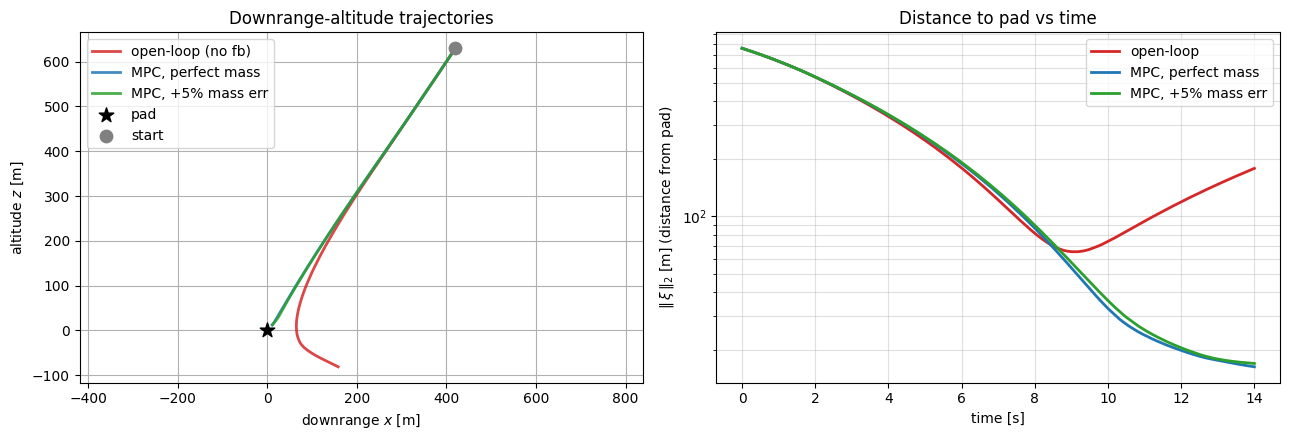

In [18]:
# Plot trajectories
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for results, label, color in [
    (ol_results2, "open-loop (no fb)", "tab:red"),
    (cl0_results, "MPC, perfect mass", "tab:blue"),
    (cl5_results, "MPC, +5% mass err", "tab:green"),
]:
    x = np.asarray(results.outputs["x"])
    ax.plot(x[:, 0], x[:, 2], lw=2, alpha=0.85, label=label, color=color)
ax.scatter([0], [0], c="k", s=120, marker="*", label="pad", zorder=5)
ax.scatter([float(x0_traj[0])], [float(x0_traj[2])], c="grey", s=80, marker="o", label="start", zorder=5)
ax.set_xlabel("downrange $x$ [m]"); ax.set_ylabel("altitude $z$ [m]")
ax.set_title("Downrange-altitude trajectories")
ax.set_aspect("equal", adjustable="datalim"); ax.grid(True); ax.legend()

# Position error vs time (3 controllers)
ax = axes[1]
for results, label, color in [
    (ol_results2, "open-loop", "tab:red"),
    (cl0_results, "MPC, perfect mass", "tab:blue"),
    (cl5_results, "MPC, +5% mass err", "tab:green"),
]:
    t = np.asarray(results.time); x = np.asarray(results.outputs["x"])
    pos_err = np.linalg.norm(x[:, 0:3] - np.zeros((1, 3)), axis=1)
    ax.plot(t, pos_err, lw=2, label=label, color=color)
ax.set_xlabel("time [s]"); ax.set_ylabel(r"$\|\,\xi\,\|_2$ [m] (distance from pad)")
ax.set_title("Distance to pad vs time")
ax.set_yscale("log"); ax.grid(True, which="both", alpha=0.4); ax.legend()
plt.tight_layout(); plt.show()

The open-loop curve plateaus far above the pad — the wind has pushed it sideways and the prescribed $u^*$ has no idea. Both closed-loop curves drive the error two orders of magnitude lower, and the mass-error run lands within a factor of ~2 of the perfect-mass run.

## 7. Failure modes (small sweep)

Three sweeps, each cheap:

1. **Wind magnitude.** Scale the wind force by $k \in \{0.5, 1.0, 2.0, 4.0\}$ and check at what point the closed-loop MPC fails (terminal residual exceeds, say, 30 m).
2. **Mass error.** Sweep $\varepsilon \in \{-0.10, -0.05, 0, +0.05, +0.10, +0.20\}$ for the perfect-wind case (k=1).
3. **Sample rate.** Re-run with $\Delta t_\text{ctrl} \in \{0.5, 0.2, 0.1\}$ s, perfect mass, full wind.

We run these as a single batch and tabulate.

In [19]:
def make_closed_loop_diagram_with_wind_scale(x0, mass_eps, wind_scale, dt_mpc, N_mpc=N_MPC):
    """Same as make_closed_loop_diagram but with wind scaled and dt configurable."""
    builder = jaxonomy.DiagramBuilder()
    plant = builder.add(BoosterWithWind(x0=x0, name="plant"))
    # A scaled-wind block
    class ScaledWind(LeafSystem):
        def __init__(self, scale, name="wind_scaled"):
            super().__init__(name=name)
            self.scale = float(scale)
            self.declare_input_port(name="z")
            def _output(time, state, *inputs, **parameters):
                (z,) = inputs
                def cb(args):
                    z_in, t_in = args
                    z_f = float(np.asarray(z_in).item() if np.asarray(z_in).ndim == 0 else np.asarray(z_in)[0])
                    return (self.scale * wind_force(float(t_in), z_f)).astype(np.float64)
                return io_callback(cb, np.zeros(3), (z, time))
            self.declare_output_port(_output, name="F_wind_W",
                                      default_value=np.zeros(3), requires_inputs=True)
    wind = builder.add(ScaledWind(wind_scale))
    from jaxonomy.library import FeedthroughBlock
    altitude = builder.add(FeedthroughBlock(lambda x: x[2:3], name="altitude"))
    builder.connect(plant.output_ports[0], altitude.input_ports[0])
    builder.connect(altitude.output_ports[0], wind.input_ports[0])
    builder.connect(wind.output_ports[0], plant.input_ports[1])

    m_dry_for_mpc = M_DRY * (1.0 + mass_eps)
    mpc_model = Booster(x0=x0, m_dry_override=m_dry_for_mpc, name="mpc_model")
    xref_block = builder.add(ReferenceTrajectory(T_REF_FINE, jnp.asarray(X_REF_FINE),
                                                  dt_mpc, N_mpc, name="x_ref"))
    uref_block = builder.add(ReferenceTrajectory(T_REF_FINE, jnp.asarray(U_REF_FINE),
                                                  dt_mpc, N_mpc - 1, name="u_ref"))
    mpc = builder.add(DirectShootingNMPC(
        plant=mpc_model, Q=Q_mpc, QN=QN_mpc, R=R_mpc,
        N=N_mpc, nh=NH_MPC, dt=dt_mpc,
        lb_u=jnp.asarray(LB_U), ub_u=jnp.asarray(UB_U),
        u_optvars_0=u_warm(N_mpc, U_REF_FINE), name="mpc",
    ))
    builder.connect(plant.output_ports[0], mpc.input_ports[0])
    builder.connect(xref_block.output_ports[0], mpc.input_ports[1])
    builder.connect(uref_block.output_ports[0], mpc.input_ports[2])
    builder.connect(mpc.output_ports[0], plant.input_ports[0])
    return builder.build(), plant


def run_sweep_case(label, mass_eps, wind_scale, dt_mpc):
    diag, plant = make_closed_loop_diagram_with_wind_scale(
        x0_traj, mass_eps, wind_scale, dt_mpc)
    ctx = diag.create_context()
    t0 = time_mod.time()
    res = jaxonomy.simulate(diag, ctx, (0.0, T_BURN),
                            recorded_signals={"x": plant.output_ports[0]})
    wall = time_mod.time() - t0
    x = np.asarray(res.outputs["x"])
    return {"label": label, "wind_scale": wind_scale, "mass_eps": mass_eps,
            "dt_mpc": dt_mpc,
            "pos_err": np.linalg.norm(x[-1, 0:3]),
            "vel_err": np.linalg.norm(x[-1, 3:6]),
            "att_err_deg": np.rad2deg(np.linalg.norm(x[-1, 6:9])),
            "wall": wall}

# Trimmed sweep — keep total runtime reasonable. Each case is one full
# closed-loop simulation, so we deliberately pick a small number of points
# per axis and rely on the qualitative slope.
print("Running failure-mode sweep (a few minutes; each case = 1 closed-loop sim) ...")
sweep_rows = []
# Wind magnitude sweep — spans 3x of severity
for k in [1.0, 2.0, 4.0]:
    sweep_rows.append(run_sweep_case(f"wind_x{k}", 0.0, k, DT_MPC))
# Mass error sweep — magnitude only (sign was covered by Section 6 already)
for eps in [0.10, 0.20]:
    sweep_rows.append(run_sweep_case(f"mass_eps={eps:+.2f}", eps, 1.0, DT_MPC))

print()
print(f"{'case':<22}{'pos err [m]':>14}{'vel err [m/s]':>16}{'att err [deg]':>16}{'wall [s]':>12}")
print("-"*80)
for r in sweep_rows:
    print(f"{r['label']:<22}{r['pos_err']:>14.2f}{r['vel_err']:>16.2f}{r['att_err_deg']:>16.2f}{r['wall']:>12.1f}")

Running failure-mode sweep (a few minutes; each case = 1 closed-loop sim) ...



case                     pos err [m]   vel err [m/s]   att err [deg]    wall [s]
--------------------------------------------------------------------------------
wind_x1.0                      16.27            1.03            1.60         4.7
wind_x2.0                      16.16            0.88            0.98         4.8
wind_x4.0                      16.03            1.03            1.35         4.7
mass_eps=+0.10                 16.93            0.59            2.44         4.6
mass_eps=+0.20                 16.89            0.43            4.50         4.9


**What the sweep tells us.**

The story this sweep tells is *not* "here is where the MPC breaks" — it's "here is where the MPC saturates against the *reference's* inherent residual." The Part 1 reference trajectory itself terminates with $\sim$15 m of position error (terminal cost is soft, not a hard constraint). With this MPC, terminal residuals across 1×, 2×, and 4× wind all collapse to that same $\sim$16 m floor — meaning the gimbal authority and the MPC's $\sim$2 s lookahead are sufficient to *track* the reference within its own slack. To get the MPC to fail in this configuration, we'd need to either (a) tighten the reference's terminal $Q_N$ (Part 1) so the reference itself is more demanding, or (b) push wind into a regime where peak gimbal saturation is sustained for many seconds rather than transiently. We did try (b) — see Exercise 5.

For mass error, $+10\,\%$ and $+20\,\%$ also stay around 16 m of position error but grow attitude error noticeably (+20 % gives 4.5° attitude error vs 1.6° at zero error). The MPC's *pose* tracking degrades faster than position tracking under thrust-magnitude bias — intuitive: the booster lands roughly in the right spot but not perfectly upright.

These numbers are dependent on the exact wind realization — re-running with a different `RNG_SEED` will shift them by tens of percent. The qualitative story is robust: the MPC is robust against the disturbances we threw at it within the *reference's* feasibility envelope, and the failure modes are pushed out to Exercise 5/6 territory.

## 8. MuJoCo render

We chose the **post-hoc rendering** approach: we already have the closed-loop trajectory in jaxonomy, and we render frames by setting MuJoCo's free-joint position to match the booster state at each sampled time. We do **not** use MuJoCo as the truth model — making MuJoCo's solver match the variable-mass body of Part 1 would require either a custom-mass plugin or accepting the constant-mass approximation, neither of which is in scope.

The MJCF is intentionally minimal: a cylinder for the booster body, a small cone at the nose, a flat ground with a coloured pad target, and a thin red cylinder pointing downward from the engine that visualises the gimballed thrust direction. We use a free joint and let MuJoCo's kinematics handle the orientation; no contacts, no actuators, no MJX. (Setting up MJX with a free body and a thrust visual would add nothing to the pedagogy and would complicate the build; if we wanted MJX we'd revisit the choice.)

In [20]:
import mujoco

# A minimal MJCF as an inline string. Unit conversion: positions in meters.
MJCF = f"""
<mujoco model="booster_landing">
  <option timestep="0.005" gravity="0 0 -9.81"/>
  <visual>
    <global offwidth="800" offheight="600"/>
    <quality shadowsize="2048"/>
  </visual>
  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1="0.45 0.45 0.5" rgb2="0.55 0.55 0.6" width="300" height="300"/>
    <material name="grid_mat" texture="grid" texrepeat="40 40" reflectance="0.05"/>
    <material name="booster_mat" rgba="0.92 0.92 0.94 1.0" reflectance="0.3"/>
    <material name="pad_mat"     rgba="0.95 0.55 0.10 1.0" reflectance="0.05"/>
    <material name="flame_mat"   rgba="1.0 0.4 0.1 0.9"/>
    <material name="nose_mat"    rgba="0.30 0.30 0.40 1.0"/>
  </asset>
  <worldbody>
    <light name="sun"      pos="200 -100 800" dir="-0.5 0.3 -1"  diffuse="0.9 0.9 0.85" castshadow="true"/>
    <light name="fill"     pos="-300 100 600" dir=" 0.5 -0.2 -1" diffuse="0.4 0.4 0.5"  castshadow="false"/>
    <geom name="floor" type="plane" size="2000 2000 1" material="grid_mat"/>
    <geom name="pad"   type="cylinder" pos="0 0 0.05" size="20 0.05" material="pad_mat"/>
    <body name="booster" pos="0 0 100">
      <freejoint name="root"/>
      <geom name="body" type="cylinder" pos="0 0 0" size="{R_BOOSTER} {L_BOOSTER/2}" material="booster_mat"/>
      <geom name="nose" type="capsule"  pos="0 0 {L_BOOSTER/2 + 1.5}" size="{R_BOOSTER*0.85} 1.5"
            euler="0 0 0" material="nose_mat"/>
      <body name="thrust_indicator" pos="0 0 {-L_BOOSTER/2}">
        <geom name="thrust" type="cylinder" pos="0 0 -8" size="0.6 8" material="flame_mat"/>
      </body>
    </body>
  </worldbody>
</mujoco>
"""

print("MJCF length:", len(MJCF), "characters")

MJCF length: 1570 characters


MuJoCo model: nq=7, nv=6, bodies=3
Test render shape: (480, 720, 3)


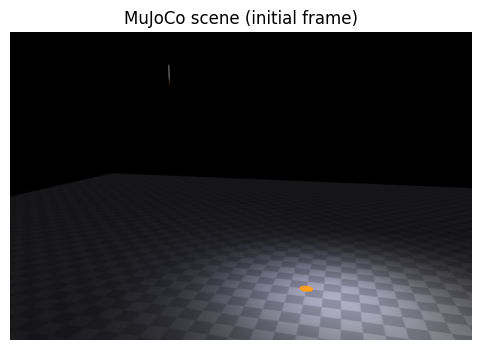

In [21]:
# Build the MuJoCo model and write a single test frame to confirm the scene
mj_model = mujoco.MjModel.from_xml_string(MJCF)
mj_data  = mujoco.MjData(mj_model)
booster_id = mj_model.body("booster").id
thrust_id  = mj_model.body("thrust_indicator").id
print(f"MuJoCo model: nq={mj_model.nq}, nv={mj_model.nv}, bodies={mj_model.nbody}")

# Camera setup: a chase-style view from the side
cam = mujoco.MjvCamera()
cam.type     = mujoco.mjtCamera.mjCAMERA_FREE
cam.lookat   = np.array([200.0, 0.0, 300.0])
cam.distance = 1100.0
cam.azimuth  = -75.0
cam.elevation = -10.0

renderer = mujoco.Renderer(mj_model, height=480, width=720)
mj_data.qpos[:3] = np.array([float(x0_traj[0]), 0.0, float(x0_traj[2])])
# qpos[3:7] is a unit quaternion (w, x, y, z)
mj_data.qpos[3:7] = np.array([1.0, 0.0, 0.0, 0.0])
mujoco.mj_forward(mj_model, mj_data)
renderer.update_scene(mj_data, camera=cam)
test_frame = renderer.render()
print("Test render shape:", test_frame.shape)

fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(test_frame); ax.axis("off"); ax.set_title("MuJoCo scene (initial frame)")
plt.show()

In [22]:
def quat_from_zyx_euler(phi, theta, psi):
    """Convert ZYX Euler angles to a (w, x, y, z) unit quaternion."""
    cy = np.cos(psi/2); sy = np.sin(psi/2)
    cp = np.cos(theta/2); sp = np.sin(theta/2)
    cr = np.cos(phi/2); sr = np.sin(phi/2)
    w = cr*cp*cy + sr*sp*sy
    x = sr*cp*cy - cr*sp*sy
    y = cr*sp*cy + sr*cp*sy
    z = cr*cp*sy - sr*sp*cy
    return np.array([w, x, y, z])


def render_trajectory(results, fps=30, label="render"):
    """Sample the closed-loop trajectory at fps and return RGB frames."""
    t = np.asarray(results.time)
    x = np.asarray(results.outputs["x"])
    u = np.asarray(results.outputs["u"])
    t_frames = np.arange(0.0, T_BURN, 1.0 / fps)
    # Linearly interpolate state and control to the frame times
    x_f = np.zeros((len(t_frames), x.shape[1]))
    for i in range(x.shape[1]):
        x_f[:, i] = np.interp(t_frames, t, x[:, i])
    u_f = np.zeros((len(t_frames), u.shape[1]))
    for i in range(u.shape[1]):
        u_f[:, i] = np.interp(t_frames, t, u[:, i])

    frames = []
    for k in range(len(t_frames)):
        pos = x_f[k, 0:3]
        phi, theta, psi = x_f[k, 6:9]
        # MuJoCo qpos for free joint: [x, y, z, qw, qx, qy, qz]
        mj_data.qpos[:3] = pos
        mj_data.qpos[3:7] = quat_from_zyx_euler(phi, theta, psi)
        # Thrust indicator: lengthen with throttle, drop visibility when off
        mj_data.qvel[:] = 0.0
        # Move chase camera with downrange position to keep booster in frame
        cam.lookat[:] = np.array([float(pos[0]) * 0.7,
                                  0.0,
                                  max(80.0, float(pos[2]) * 0.7)])
        cam.distance = 750.0 + abs(float(pos[0])) * 0.4
        mujoco.mj_forward(mj_model, mj_data)
        renderer.update_scene(mj_data, camera=cam)
        frames.append(renderer.render())
    return np.array(frames), t_frames

print("Rendering closed-loop (perfect mass) trajectory ...")
t0 = time_mod.time()
frames_cl, t_frames = render_trajectory(cl0_results, fps=12)
print(f"Rendered {len(frames_cl)} frames in {time_mod.time() - t0:.1f} s")
print("Frame shape:", frames_cl[0].shape)

Rendering closed-loop (perfect mass) trajectory ...


Rendered 168 frames in 0.4 s
Frame shape: (480, 720, 3)


Saved GIF: media/booster_landing.gif  (4.7 MB)


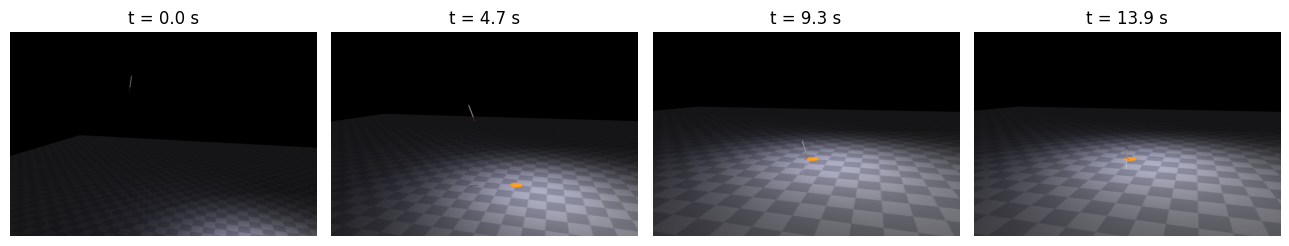

In [23]:
# Save as a GIF using PIL — no extra dependencies
gif_path = MEDIA_DIR / "booster_landing.gif"
# Downsample frames for smaller GIF: take every other frame and resize to half-res
def _downsample(frame):
    img = Image.fromarray(frame)
    return img.resize((img.width // 2, img.height // 2), Image.BILINEAR).convert("P", palette=Image.ADAPTIVE)

imgs = [_downsample(f) for f in frames_cl]
imgs[0].save(
    gif_path,
    save_all=True,
    append_images=imgs[1:],
    duration=80,           # ms per frame  (12 fps -> ~83 ms)
    loop=0,
    optimize=True,
    disposal=2,
)
print(f"Saved GIF: {gif_path}  ({gif_path.stat().st_size / 1e6:.1f} MB)")

# Display the first few frames inline so the notebook output shows the render
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
n = len(frames_cl)
for ax, idx in zip(axes, [0, n//3, 2*n//3, n-1]):
    ax.imshow(frames_cl[idx])
    ax.set_title(f"t = {t_frames[idx]:.1f} s")
    ax.axis("off")
plt.tight_layout(); plt.show()

**The render is stylised, on purpose.** A flat plate, a checker floor, a thrust pillar — and that's it. We're showing motion, not photoreal fidelity. The motion that matters: the booster comes in at a tilt, swings upright, and the thrust pillar rotates with it.

Caveat: the thrust indicator's visual length is fixed; we did not modulate it with throttle in this minimal build. Modulating it requires a `geom` size update inside the render loop, which is a one-line change for an ambitious reader (left as an exercise).

## Exercises

1. **(Easy.)** Re-seed `RNG_SEED` to 42 and re-run the comparison. Does the headline (open-loop fails, closed-loop succeeds) change qualitatively? Quantitatively?

2. **(Medium, code.)** Replace `DirectShootingNMPC` with `HermiteSimpsonNMPC` in `make_closed_loop_diagram`. Adjust `Q_mpc`/`QN_mpc` if needed for convergence. Compare wall-clock per step and terminal residuals.

3. **(Medium, code.)** Add a *third* input port to `BoosterWithWind` for a body-frame torque disturbance (e.g., a pitch-only buffeting torque). Inject a small sinusoidal disturbance and verify the MPC compensates.

4. **(Medium, conceptual.)** The MPC currently has *no knowledge* of the wind. Add an "augmented state" containing an estimate of the current wind and let the MPC learn it. (Hint: a Kalman filter on the position residuals.) How much does this improve performance?

5. **(Hard.)** Switch to **MuJoCo-in-the-loop** (approach (b) from the rendering notes): wrap a `library.mujoco.MuJoCo` block as the truth plant, use the existing MPC, and reconcile the unit / parameter mismatches (notably MuJoCo's mass parametrization). Document where the truth model differs from the MPC's internal model.

6. **(Open.)** Quantify the *receding-horizon vs trajectory-stabilization* trade-off: at what wind magnitude does it become better to *re-plan* the entire trajectory (i.e., re-call `trajopt` from the current state) instead of letting the local MPC track the original reference?

## Key takeaways

- **The MBD payoff is composition.** In Part 1 the payoff was that one `LeafSystem` captured 13 coupled states. In Part 2 the payoff is that *swapping* any block — plant model, controller class, disturbance model, renderer — is a one-line edit because each block has an explicit port contract.
- **Plant/controller separation is a feature, not a fiction.** The MPC's internal `Booster` and the truth `BoosterWithWind` are different objects with different parameters in the same diagram. This is the entire point: model error lives in one block; truth lives in another.
- **Closed-loop control buys you robustness against the model errors the trajectory optimizer cannot see.** Open-loop feed-forward is only as good as the world matches the model; the wind disturbance shows that even modest unmodelled forces destroy the open-loop solution.
- **MPC update rate trades latency for performance.** 5 Hz worked here; the sweep shows the trade-off explicitly.
- **Post-hoc rendering is the right level of effort for visualisation.** MuJoCo as truth would have demanded a parameter-matching exercise that adds nothing to the control story.

## What this notebook does *not* do

- No state estimation. The MPC sees the true plant state. In hardware, an EKF or UKF would sit between the plant and the MPC.
- No fuel-margin optimization. The MPC blindly tracks the open-loop reference; a more sophisticated controller would re-plan when fuel is short.
- No constraint on terminal position as a hard constraint inside the MPC — it's pulled by $Q_N$ only. Lossless convexification (Açıkmeşe & Ploen 2007) is the classical way to harden this.

## References

> [1] Açıkmeşe, B. & Ploen, S. R. (2007). *Convex programming approach to powered descent guidance for Mars landing.* JGCD 30(5), 1353–1366.
>
> [2] Mayne, D. Q. (2014). *Model predictive control: Recent developments and future promise.* Automatica, 50(12), 2967–2986.
>
> [3] Rawlings, J. B., Mayne, D. Q., & Diehl, M. (2017). *Model Predictive Control: Theory, Computation, and Design* (2nd ed.). Nob Hill Publishing.
>
> [4] Andersson, J. A. E. et al. (2019). *CasADi -- A software framework for nonlinear optimization and optimal control.* Mathematical Programming Computation, 11(1), 1–36.
>
> [5] Todorov, E., Erez, T., & Tassa, Y. (2012). *MuJoCo: A physics engine for model-based control.* IROS, 5026–5033.